<a href="https://colab.research.google.com/github/vpattangi/tone-discourse-classification/blob/main/emoji_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emoji Use In Online Discourse

####This project uses the "1 Million Reddit Comments from 40 Subreddits" dataset from Kaggle:

https://www.kaggle.com/datasets/smagnan/1-million-reddit-comments-from-40-subreddits

How to get the data:
* Go to the link above
* Click "Download"
* Extract the ZIP file
* Locate the file: kaggle_RC_2019-05.csv

How to use it:
* When running the notebook in Google Colab: upload kaggle_RC_2019-05.csv

This project investigates how emojis, specifically the skull (💀) and loudly crying face (😭), function as linguistic markers of emotional intensity in digital communication.

Using a large-scale dataset of Reddit comments (May 2019), this study analyzes over one million entries to explore how emoji usage varies across different online communities, including sports, gaming, memes, and political discussions.

The project focuses on identifying patterns such as:
- Repeated emoji usage as a form of emotional amplification
- Differences between informal (emoji-rich) and formal (emoji-free) communication
- The relationship between topic context and expressive language

By combining quantitative data analysis with linguistic theory, this study highlights how modern online discourse blends text and visual symbols to convey tone, humor, and exaggerated emotion.

## How to run this notebook

1. Upload `kaggle_RC_2019-05.csv` to the Colab session (left sidebar, Files).
2. Choose **Runtime > Run all**. Everything runs top to bottom, so no cell needs to be run by hand or in a special order.
3. Near the end, a file picker appears: select `cry_v2_labeled.csv` and `skull_v2_labeled.csv` together.

Checkpoints: the first code cell should print `File size (MB): 185.9` and `Rows loaded: 1000000`. If it does not, the raw file was not fully uploaded, so delete it and upload it again.

Generated CSVs are not downloaded automatically. Set `DOWNLOAD_OUTPUTS = True` in the first code cell if you want copies on your computer.


## Cleaning The Dataset

####Load Dataset

In [ ]:
import os, html, pandas as pd

# Set to True if you want the generated CSVs downloaded to your computer
DOWNLOAD_OUTPUTS = False

RAW_PATH = "/content/kaggle_RC_2019-05.csv"
if not os.path.exists(RAW_PATH):
    raise FileNotFoundError("Upload kaggle_RC_2019-05.csv to /content/ first (Colab sidebar > Files).")
print("File size (MB):", round(os.path.getsize(RAW_PATH) / 1e6, 1))

df = pd.read_csv(RAW_PATH, engine="python", on_bad_lines="skip")
print("Rows loaded:", len(df))

valid_sub = df["subreddit"].astype(str).str.fullmatch(r"[A-Za-z0-9_]{2,21}")
print("Malformed-subreddit rows dropped:", (~valid_sub).sum())
df = df[valid_sub].dropna(subset=["body"]).copy()
df["body"] = df["body"].apply(html.unescape)

raw_df = df   # reused by the serious-tone section below, so the raw file is only read once


File size (MB): 185.9
Rows loaded: 1000000
Malformed-subreddit rows dropped: 0


####Filter for emojis

In [ ]:
filtered = df[df["body"].str.contains("💀|😭", na=False)]
filtered.head()

,subreddit,body,controversiality,score
5123,AskReddit,"Beading. \n\nWatching my pet chickens, when I ...",0,1
5232,FortNiteBR,Lmao 💀💀 y’all some funny bulls,0,2
5248,funny,"So technically apps that have ""lite"" ar the en...",0,3
6918,RoastMe,🙌🖕💀 go to hell with ur kleenexs too,0,-1
8806,gameofthrones,Skyrim is probably the closest we’re gonna get...,0,2


#### Remove Spam, Duplicates, and Non-English Comments


In [ ]:
import re

SPAM_MARKERS = ["Noobmaster", "CUM-RADE"]   # copy-pasted copypasta

def is_emoji_spam(text):
    text = str(text)
    many_symbols = len(set(re.findall(r"[^\w\s.,!?'\"]", text))) > 15   # pasted emoji lists, emoji walls
    return many_symbols or any(m in text for m in SPAM_MARKERS)

def is_non_english(text):
    return bool(re.search(r"[\u0400-\u04FF\u4E00-\u9FFF\u3040-\u30FF\uAC00-\uD7AF]", str(text)))

n_before = len(filtered)
filtered = filtered[~filtered["body"].apply(is_emoji_spam)]
filtered = filtered[~filtered["body"].apply(is_non_english)]
filtered = filtered.drop_duplicates(subset="body")
print(f"Removed {n_before - len(filtered)} spam / non-English / duplicate comments; {len(filtered)} remain")
print("Skull:", filtered["body"].str.contains("💀").sum(), "| Crying:", filtered["body"].str.contains("😭").sum())


Removed 16 spam / non-English / duplicate comments; 488 remain
Skull: 50 | Crying: 438


####Save Cleaned Dataset

In [ ]:
filtered.to_csv("cleaned_emoji_data.csv", index=False)

####Download Cleaned Dataset

In [ ]:
from google.colab import files
if DOWNLOAD_OUTPUTS:
    files.download("cleaned_emoji_data.csv")


## Reddit Category Classification

To better understand how language and emoji usage vary across different types of online communities, each Reddit comment is categorized based on its subreddit.

Subreddits are grouped into broader thematic categories, including:
- Sports (e.g., NBA, NFL)
- Gaming (e.g., Fortnite, Minecraft)
- Memes/Humor
- Politics/News
- Other

This classification allows the dataset to be analyzed at a higher level, making it possible to compare how different communities communicate.

For example, meme and gaming communities are expected to use more emojis and exaggerated expressions, while political and news-related discussions tend to be more formal and emoji-free.

By organizing the data into categories, this step enables both quantitative analysis (e.g., frequency of emoji use) and qualitative insights into how tone and emotional expression differ across contexts.

####Load Cleaned Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_emoji_data.csv")
df.head()

,subreddit,body,controversiality,score
0,AskReddit,"Beading. \n\nWatching my pet chickens, when I ...",0,1
1,FortNiteBR,Lmao 💀💀 y’all some funny bulls,0,2
2,funny,"So technically apps that have ""lite"" ar the en...",0,3
3,RoastMe,🙌🖕💀 go to hell with ur kleenexs too,0,-1
4,gameofthrones,Skyrim is probably the closest we’re gonna get...,0,2


#### Creating Subreddit Categories

In [ ]:
def categorize_topic(subreddit):
    subreddit = str(subreddit).lower()

    # sports
    if any(word in subreddit for word in ["nba", "nfl", "soccer", "hockey", "sports", "baseball"]):
        return "sports"

    # gaming
    elif any(word in subreddit for word in ["gaming", "xbox", "pcgaming", "fortnite", "apex", "cod", "minecraft"]):
        return "gaming"

    # memes / humor
    elif any(word in subreddit for word in ["funny", "memes", "dankmemes"]):
        return "memes"

    # politics / serious
    elif any(word in subreddit for word in ["politics", "news", "worldnews"]):
        return "politics"

    else:
        return "other"

#### Apply Category Sorting to Dataset

In [ ]:
df["topic"] = df["subreddit"].apply(categorize_topic)

df.head()

,subreddit,body,controversiality,score,topic
0,AskReddit,"Beading. \n\nWatching my pet chickens, when I ...",0,1,other
1,FortNiteBR,Lmao 💀💀 y’all some funny bulls,0,2,gaming
2,funny,"So technically apps that have ""lite"" ar the en...",0,3,memes
3,RoastMe,🙌🖕💀 go to hell with ur kleenexs too,0,-1,other
4,gameofthrones,Skyrim is probably the closest we’re gonna get...,0,2,other


#### Lines Per Category Count

In [ ]:
df["topic"].value_counts()

,count
topic,
other,365
gaming,50
memes,40
sports,29
politics,4


#### Compare Emoji Usage by Topic

In [ ]:
def get_emoji_type(text):
    if pd.isna(text):
        return "none"
    has_skull = "💀" in text
    has_cry = "😭" in text

    if has_skull and has_cry:
        return "mixed"
    elif has_skull:
        return "skull"
    elif has_cry:
        return "crying"
    else:
        return "none"

df["emoji_type"] = df["body"].apply(get_emoji_type)

In [ ]:
pd.crosstab(df["topic"], df["emoji_type"])

emoji_type,crying,skull
topic,,
gaming,44,6
memes,37,3
other,332,33
politics,4,0
sports,21,8


#### Examples Per Topic

In [ ]:
from IPython.display import display
display(df[df["topic"] == "sports"].head(5))
display(df[df["topic"] == "gaming"].head(5))
display(df[df["topic"] == "memes"].head(5))

,subreddit,body,controversiality,score,topic,emoji_type
8,nba,Imagine being a bucks fan and really thinking ...,1,-1,sports,skull
25,nba,Kenny got up so quick 💀,0,7,sports,skull
37,hockey,I love Bob 😭,0,20,sports,crying
41,nba,I switch this off and came back an hour later ...,0,2,sports,crying
50,hockey,The Sharks power play is bad hahaha 🤣😂😭😭😭,1,2,sports,crying


,subreddit,body,controversiality,score,topic,emoji_type
1,FortNiteBR,Lmao 💀💀 y’all some funny bulls,0,2,gaming,skull
5,FortNiteBR,I WANT DREAM FEET 😭😭,0,1,gaming,crying
11,FortNiteBR,Lmaaooo 💀💀 why? Sole nah,0,1,gaming,skull
15,FortNiteBR,Where is spandex squad?! 😭,0,1,gaming,crying
42,apexlegends,We don’t talk about paragon 😭😭😭😭 F,0,13,gaming,crying


,subreddit,body,controversiality,score,topic,emoji_type
2,funny,"So technically apps that have ""lite"" ar the en...",0,3,memes,crying
6,funny,That's an ugly fucking kid tho I'm dead 😭,0,1,memes,crying
10,memes,If only this were true and we could actually m...,0,3,memes,crying
30,memes,RIP unsettled Tom he will always be remembered 😭😭,0,7,memes,crying
34,funny,">...but how could a shoe, talk to you, the cut...",0,2,memes,crying


#### Save Final Dataset

In [ ]:
df.to_csv("final_emoji_topic_dataset.csv", index=False)

##Emoji Intensification Classification

Emoji intensification is defined as the repetition of emojis within a single comment to amplify emotional meaning.

This functions as a paralinguistic feature of digital language, where repeated symbols (e.g., 💀💀💀, 😭😭😭) enhance the perceived intensity of an expression beyond what text alone conveys.

In this analysis, comments are categorized into:
- Single emoji use (casual expression)
- Repeated emoji use (intensified emotion)

This distinction allows for a more nuanced understanding of how emotional emphasis is constructed in online communication.

#### Emoji Intensification Identification

In [ ]:
import pandas as pd
import re

# load dataset
df = pd.read_csv("cleaned_emoji_data.csv")

# detect repeated emojis
def has_repeated_emoji(text):
    if pd.isna(text):
        return False
    return text.count("💀") >= 2 or text.count("😭") >= 2

# filter
intensified_comments = df[df["body"].apply(has_repeated_emoji)]

# print results
print("Emoji Intensification Comments:")
for i, row in intensified_comments.iterrows():
    print(f"Subreddit: {row['subreddit']}")
    print(f"Comment: {row['body']}")
    print("-" * 50)

# save to CSV
intensified_comments.to_csv("emoji_intensification.csv", index=False)

print("\nSaved to emoji_intensification.csv")

Emoji Intensification Comments:
Subreddit: FortNiteBR
Comment: Lmao 💀💀 y’all some funny bulls
--------------------------------------------------
Subreddit: gameofthrones
Comment: Skyrim is probably the closest we’re gonna get for a while 😭😭
--------------------------------------------------
Subreddit: FortNiteBR
Comment: I WANT DREAM FEET 😭😭
--------------------------------------------------
Subreddit: freefolk
Comment: Yeah. I never liked Theon. Never gave a shit. Then just watching him kill like 25 dudes alone. The heart it takes to be the last man standing in the position and he has 6 friggin fingers. Then crows nest over there tipped me over with the “...you’re a good man.” Ugh🥺🥺😭😭
--------------------------------------------------
Subreddit: nba
Comment: Imagine being a bucks fan and really thinking Giannis is the best player in the world 💀💀💀💀💀
--------------------------------------------------
Subreddit: memes
Comment: If only this were true and we could actually make stan lee 😭😭

## Serious-Tone Reddit Comment Classification

Serious tone is defined as the absence of emojis in comments, particularly within politics and news-related subreddits.

This form of communication relies on textual language alone and reflects a more formal register, where emotional expression is minimized. In contrast to emoji-based discourse, serious comments prioritize clarity, argumentation, and informational content.

This category serves as a baseline for comparison, allowing the analysis to examine how the presence or absence of emojis influences tone, emotional intensity, and communicative style.

#### Reddit Classification for Serious-Tone Comments

In [ ]:
import pandas as pd
import re

# reuse the raw data loaded (and cleaned) in the first code cell
if "raw_df" not in globals():
    raise RuntimeError("Run the first code cell (Load Dataset) before this one.")
src = raw_df

# filter politics/news
def is_politics_news(subreddit):
    subreddit = str(subreddit).lower()
    return any(word in subreddit for word in ["politics", "news", "worldnews"])

# check no emojis
def has_no_emoji(text):
    if pd.isna(text):
        return False
    return not bool(re.search(r'💀|😭', text))

# filter dataset
serious_comments = src[
    src["subreddit"].apply(is_politics_news) &
    src["body"].apply(has_no_emoji)
]

# print sample
print("Sample of Serious Tone:")

for i, row in serious_comments.head(20).iterrows():
    print(f"Subreddit: {row['subreddit']}")
    print(f"Comment: {row['body']}")
    print("-" * 50)

# save to CSV
serious_comments.to_csv("politics_news_no_emoji.csv", index=False)

print("\nSaved to politics_news_no_emoji.csv")
print("Total rows:", len(serious_comments))


Sample of Serious Tone:
Subreddit: news
Comment: You know we have laws against that currently correct? Or are you just willfully ignorant of gun laws in the US.
--------------------------------------------------
Subreddit: politics
Comment: Yes, there is a difference between gentle suppression and hard suppression.  Neither are good things.
--------------------------------------------------
Subreddit: worldnews
Comment: How many millions have to suffer and die for them to feel any of that pain though?
--------------------------------------------------
Subreddit: news
Comment: No, not really at all. It happens too often but it's ridiculous to pretend that applies to everyone.
--------------------------------------------------
Subreddit: news
Comment: This is disgusting every week
--------------------------------------------------
Subreddit: worldnews
Comment: Trump's administration is lying on Fox news? I can't believe it!
--------------------------------------------------
Subreddit: wo

## Full Uploaded And Organized Dataset + Dashboard

The final dataset integrates multiple processed data sources into a single, structured file for analysis.

It combines:
- Emoji-containing comments (💀, 😭) from the cleaned dataset
- Emoji-free comments from politics and news subreddits in the original dataset

Each comment is enriched with additional features, including:
- Subreddit (source community)
- Category (e.g., sports, gaming, memes, politics)
- Emoji type (skull, crying, mixed, or none)
- Emoji intensity (single or repeated)
- Tone classification (casual, intensified emotion, or serious)

This structured dataset enables direct comparison between different communication styles, allowing the analysis to examine how emoji use, emotional intensity, and topic context interact in online discourse.

By organizing the data in this way, the project moves beyond simple filtering and creates a comprehensive framework for both quantitative and qualitative linguistic analysis.

Dashboard:

This efficiently classifies and allows to check emoji specific data, as well as specific Reddit emoji data being used for this project.

#### Intall Necessary Packages

In [ ]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.7 MB/s eta 0:00:00


#### Data Preperation

In [ ]:
import pandas as pd

emoji_df = pd.read_csv("cleaned_emoji_data.csv")
serious_df = pd.read_csv("politics_news_no_emoji.csv")

def detect_emoji_type(text):
    text = str(text)
    has_skull = "💀" in text
    has_cry = "😭" in text
    if has_skull and has_cry:
        return "mixed"
    elif has_skull:
        return "skull"
    elif has_cry:
        return "crying"
    else:
        return "none"

def emoji_intensity(text):
    text = str(text)
    return text.count("😭") + text.count("💀")

# same category terms as "Creating Subreddit Categories" above, so the two sections agree
def categorize_subreddit(sub):
    sub = str(sub).lower()
    if any(x in sub for x in ["nba", "nfl", "soccer", "hockey", "sports", "baseball"]):
        return "sports"
    elif any(x in sub for x in ["gaming", "xbox", "pcgaming", "fortnite", "apex", "cod", "minecraft"]):
        return "gaming"
    elif any(x in sub for x in ["funny", "memes", "dankmemes"]):
        return "memes"
    elif any(x in sub for x in ["politics", "news", "worldnews"]):
        return "politics"
    else:
        return "other"

def classify_tone(row):
    if row["category"] == "politics" and row["emoji_type"] == "none":
        return "serious"
    elif row["emoji_intensity"] >= 2:
        return "intensified emotion"
    else:
        return "casual"

# Build features for the emoji-containing comments
emoji_df["emoji_type"] = emoji_df["body"].apply(detect_emoji_type)
emoji_df["emoji_intensity"] = emoji_df["body"].apply(emoji_intensity)
emoji_df["category"] = emoji_df["subreddit"].apply(categorize_subreddit)

# Build matching features for the emoji-free serious comments
serious_df["emoji_type"] = "none"
serious_df["emoji_intensity"] = 0
serious_df["category"] = "politics"

# Combine both sources into one structured dataset
final_df = pd.concat([emoji_df, serious_df], ignore_index=True)
final_df["tone"] = final_df.apply(classify_tone, axis=1)

final_df.to_csv("FINAL_FULL_DATASET.csv", index=False)

print("FINAL DATASET CREATED")
print(final_df["emoji_type"].value_counts())
print(final_df["tone"].value_counts())

FINAL DATASET CREATED
emoji_type
none      74996
crying      438
skull        50
Name: count, dtype: int64
tone
serious                74996
casual                   351
intensified emotion      137
Name: count, dtype: int64


In [ ]:
import pandas as pd
from google.colab import files

df = pd.read_csv("FINAL_FULL_DATASET.csv")
print(df.columns)

if DOWNLOAD_OUTPUTS:
    files.download("FINAL_FULL_DATASET.csv")


Index(['subreddit', 'body', 'controversiality', 'score', 'emoji_type',
       'emoji_intensity', 'category', 'tone'],
      dtype='object')


#### Dashboard Interactive Button System

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

df = pd.read_csv("FINAL_FULL_DATASET.csv")

print("Columns:", df.columns)
print("Total rows:", len(df))

output = widgets.Output()

def category_data(emoji):
    sports_terms = ["nba", "nfl", "soccer", "basketball", "football", "hockey"]
    gaming_terms = ["gaming", "ps5", "xbox", "pcgaming"]
    meme_terms = ["meme", "memes", "funny", "dankmemes"]

    def match_category(sub):
        sub = str(sub).lower()
        return (
            any(x in sub for x in sports_terms) or
            any(x in sub for x in gaming_terms) or
            any(x in sub for x in meme_terms)
        )

    return df[
        (df["emoji_type"] == emoji) &
        (df["subreddit"].apply(match_category))
    ][["subreddit", "body", "category", "emoji_intensity"]]

def full_data(emoji):
    return df[df["emoji_type"] == emoji][
        ["subreddit", "body", "category", "emoji_intensity"]
    ]

def serious_full():
    return df[df["emoji_type"] == "none"][
        ["subreddit", "body", "category"]
    ]

def serious_news_politics():
    terms = ["news", "politics"]
    return df[
        (df["emoji_type"] == "none") &
        (df["subreddit"].str.lower().apply(lambda x: any(t in x for t in terms)))
    ][["subreddit", "body", "category"]]

def show_table(data):
    with output:
        clear_output()
        print(f"Total rows: {len(data)}")
        display(data)

def emoji_menu(emoji_name):
    btn_full = widgets.Button(description="📊 Full Data")
    btn_cat = widgets.Button(description="🎯 Sports/Gaming/Memes")

    btn_full.on_click(lambda x: show_table(full_data(emoji_name)))
    btn_cat.on_click(lambda x: show_table(category_data(emoji_name)))

    return widgets.VBox([btn_full, btn_cat])

def serious_menu():
    btn_full = widgets.Button(description="📊 Full Data")
    btn_np = widgets.Button(description="📰 News/Politics")

    btn_full.on_click(lambda x: show_table(serious_full()))
    btn_np.on_click(lambda x: show_table(serious_news_politics()))

    return widgets.VBox([btn_full, btn_np])

btn_cry = widgets.Button(description="😭 Crying Emoji")
btn_skull = widgets.Button(description="💀 Skull Emoji")
btn_serious = widgets.Button(description="📰 Serious Tone")

def click_cry(b):
    with output:
        clear_output()
        display(emoji_menu("crying"))

def click_skull(b):
    with output:
        clear_output()
        display(emoji_menu("skull"))

def click_serious(b):
    with output:
        clear_output()
        display(serious_menu())

btn_cry.on_click(click_cry)
btn_skull.on_click(click_skull)
btn_serious.on_click(click_serious)

display(widgets.HBox([btn_cry, btn_skull, btn_serious]))
display(output)

Columns: Index(['subreddit', 'body', 'controversiality', 'score', 'emoji_type',
       'emoji_intensity', 'category', 'tone'],
      dtype='object')
Total rows: 75484


Output()

#NLP Prediction Model Implementation

This section tests whether the surrounding text of a comment can predict the sense in which an emoji is being used: literal (its dictionary meaning) versus figurative (a repurposed, often hyperbolic meaning). The emoji itself is removed from each comment before training, so the model must rely entirely on context. Text is converted into numerical features using TF-IDF, which weighs distinctive words and phrases more heavily than common ones, then a logistic regression classifier is trained to predict sense from those features.

The dataset is split into training and testing sets so the model is evaluated on unseen comments rather than ones it was trained on. Because comments matching a clear literal or figurative sense were rare, class balance is checked before training, and performance is reported using precision, recall, and F1-score per class (rather than accuracy alone) so that performance on the minority class isn't masked by the majority class. A low-confidence rate, the share of predictions where the model's top probability sits close to a coin flip, is also reported, since frequent low-confidence predictions indicate that context often fails to resolve which sense is intended, which is itself evidence of the emoji's ambiguity.

> **Note:** This supervised-classifier approach was the first attempt. Too few comments carried a clear literal or figurative cue to train a model for each emoji, so the models below are skipped (see the class counts in the output). The primary method is the semantic-similarity analysis that follows, which is checked against reviewed labels.


#### NLP Prediction Model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Use the curated emoji-only file, not the full imbalanced dataset
emoji_df = pd.read_csv("cleaned_emoji_data.csv")

def build_sense_dataset(df, emoji_char, literal_cues, figurative_cues):
    subset = df[df["body"].str.contains(emoji_char, na=False)].copy()

    def heuristic_sense(text):
        text = str(text).lower()
        if any(c in text for c in literal_cues):
            return "literal"
        elif any(c in text for c in figurative_cues):
            return "figurative"
        return None

    subset["sense"] = subset["body"].apply(heuristic_sense)

    total = len(subset)
    unlabeled = subset["sense"].isna().sum()
    print(f"{emoji_char}: {total} total comments, {unlabeled} ({unlabeled/total:.1%}) "
          f"had no clear literal/figurative cue -- these are candidates for manual "
          f"review and are themselves evidence of ambiguity.\n")

    subset = subset.dropna(subset=["sense"])
    subset["context_only"] = subset["body"].str.replace(emoji_char, "", regex=False)
    return subset

def train_sense_model(subset, label):
    counts = subset["sense"].value_counts()
    print(f"=== {label} class counts ===\n{counts}\n")

    if len(counts) < 2 or counts.min() < 5:
        print(f"Skipping model for {label}: too few examples in one class "
              f"after heuristic labeling (need at least 5 per class). This "
              f"itself suggests {label} usage is heavily skewed toward one "
              f"sense in this dataset -- worth reporting as a finding rather "
              f"than forcing a classifier split.\n")
        return None, None

    X_train, X_test, y_train, y_test = train_test_split(
        subset["context_only"], subset["sense"],
        test_size=0.2, random_state=42, stratify=subset["sense"]
    )

    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)
    y_proba = model.predict_proba(X_test_vec)

    print(f"=== {label} classification report ===")
    print(classification_report(y_test, y_pred))

    confidence = np.max(y_proba, axis=1)
    ambiguous_rate = np.mean(confidence < 0.65)
    print(f"Share of low-confidence (<0.65) predictions: {ambiguous_rate:.1%}\n")

    return model, vectorizer

skull_cues_literal = ["rip", "r.i.p", "passed away", "funeral", "sorry for your loss",
                       "died", "death", "gone too soon", "condolences", "mourning",
                       "grief", "obituary", "killed", "murdered", "suicide", "tragic",
                       "in loving memory", "lost his life", "lost her life"]
skull_cues_figurative = ["lmao", "lol", "hilarious", "dead", "insane", "wild", "bro",
                          "im dead", "im dying", "so funny", "lmaooo", "deadass"]

cry_cues_literal = ["miss you", "hurts", "lost my", "grieving", "heartbroken",
                     "sorry for your loss", "passed away", "condolences", "funeral",
                     "so sad", "devastated", "cried myself"]
cry_cues_figurative = ["lmao", "hilarious", "im dead", "cant stop laughing", "so funny",
                        "crying laughing", "im crying rn", "sobbing lmao"]

skull_data = build_sense_dataset(emoji_df, "💀", skull_cues_literal, skull_cues_figurative)
cry_data = build_sense_dataset(emoji_df, "😭", cry_cues_literal, cry_cues_figurative)

skull_model, skull_vec = train_sense_model(skull_data, "Skull Emoji (💀)")
cry_model, cry_vec = train_sense_model(cry_data, "Crying Emoji (😭)")

💀: 50 total comments, 40 (80.0%) had no clear literal/figurative cue -- these are candidates for manual review and are themselves evidence of ambiguity.

😭: 438 total comments, 427 (97.5%) had no clear literal/figurative cue -- these are candidates for manual review and are themselves evidence of ambiguity.

=== Skull Emoji (💀) class counts ===
sense
figurative    9
literal       1
Name: count, dtype: int64

Skipping model for Skull Emoji (💀): too few examples in one class after heuristic labeling (need at least 5 per class). This itself suggests Skull Emoji (💀) usage is heavily skewed toward one sense in this dataset -- worth reporting as a finding rather than forcing a classifier split.

=== Crying Emoji (😭) class counts ===
sense
literal       7
figurative    4
Name: count, dtype: int64

Skipping model for Crying Emoji (😭): too few examples in one class after heuristic labeling (need at least 5 per class). This itself suggests Crying Emoji (😭) usage is heavily skewed toward one sens

#### Demo

In [ ]:
def show_top_cues(model, vectorizer, label, n=15):
    if model is None:
        print(f"=== {label} === (skipped -- not enough data for both classes)\n")
        return
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = model.coef_[0]
    top_figurative = feature_names[np.argsort(coefs)[-n:]]
    top_literal = feature_names[np.argsort(coefs)[:n]]
    print(f"=== {label} ===")
    print("Top figurative cues:", list(top_figurative))
    print("Top literal cues:", list(top_literal))
    print()

show_top_cues(skull_model, skull_vec, "Skull Emoji (💀)")
show_top_cues(cry_model, cry_vec, "Crying Emoji (😭)")

# Test on sentences that ACTUALLY contain the emoji -- this is the real test:
# does context tell us which sense is meant?
skull_test = [
    "rip to my grandfather, he passed away last night 💀",
    "bro this game is so insane 💀",
    "that joke was unexpectedly dark 💀"
]
cry_test = [
    "i just found out my dog passed away 😭",
    "this is the funniest video ive ever seen 😭",
    "i wasnt ready for that ending 😭"
]

if skull_model is not None:
    skull_vecs = skull_vec.transform([s.replace("💀", "") for s in skull_test])
    print("Skull sense predictions:")
    for text, pred in zip(skull_test, skull_model.predict(skull_vecs)):
        print(f"  {pred:12s} | {text}")
else:
    print("Skull model unavailable -- see class counts above.")

print()

if cry_model is not None:
    cry_vecs = cry_vec.transform([s.replace("😭", "") for s in cry_test])
    print("Crying sense predictions:")
    for text, pred in zip(cry_test, cry_model.predict(cry_vecs)):
        print(f"  {pred:12s} | {text}")
else:
    print("Crying model unavailable -- see class counts above.")

=== Skull Emoji (💀) === (skipped -- not enough data for both classes)

=== Crying Emoji (😭) === (skipped -- not enough data for both classes)

Skull model unavailable -- see class counts above.

Crying model unavailable -- see class counts above.


#### Optional: Export Comments for Labeling


In [ ]:
# Already done for this project: the labeled files are cry_v2_labeled.csv and skull_v2_labeled.csv.
# Only needed if you want to re-export the comments for labeling again.
skull_rows = emoji_df[emoji_df["body"].str.contains("💀", na=False)].copy()
cry_rows = emoji_df[emoji_df["body"].str.contains("😭", na=False)].copy()

skull_rows["manual_sense"] = ""
cry_rows["manual_sense"] = ""

skull_rows[["subreddit", "body", "manual_sense"]].to_csv("skull_to_label.csv", index=False)
cry_rows[["subreddit", "body", "manual_sense"]].to_csv("cry_to_label.csv", index=False)

print(f"Exported {len(skull_rows)} skull comments to skull_to_label.csv")
print(f"Exported {len(cry_rows)} crying comments to cry_to_label.csv")

if DOWNLOAD_OUTPUTS:
    from google.colab import files
    files.download("skull_to_label.csv")
    files.download("cry_to_label.csv")


Exported 50 skull comments to skull_to_label.csv
Exported 438 crying comments to cry_to_label.csv


In [ ]:
!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer, util
import pandas as pd

THRESHOLD = 0.35   # similarity below this = "ambiguous" (checked against reviewed labels below)

# always read the current cleaned file, so these scores can never be stale
emoji_df = pd.read_csv("cleaned_emoji_data.csv")
print("Comments loaded:", len(emoji_df))

model = SentenceTransformer('all-MiniLM-L6-v2')

LITERAL_ANCHORS = {
    "💀": ["death", "someone dying", "a dangerous situation", "mortality", "a funeral"],
    "😭": ["deep sadness", "grief", "crying from sorrow", "heartbreak", "mourning a loss"],
}

anchor_embeddings = {
    emoji: model.encode(anchors, convert_to_tensor=True)
    for emoji, anchors in LITERAL_ANCHORS.items()
}

def semantic_ambiguity_score(text, emoji_char, threshold=THRESHOLD):
    context_embedding = model.encode(text, convert_to_tensor=True)
    similarities = util.cos_sim(context_embedding, anchor_embeddings[emoji_char])
    max_sim = float(similarities.max())
    return max_sim, max_sim < threshold

def analyze_ambiguity(df, emoji_char, threshold=THRESHOLD):
    subset = df[df["body"].str.contains(emoji_char, na=False)].copy()
    subset["context_text"] = subset["body"].str.replace(emoji_char, "", regex=False)

    results = subset["context_text"].apply(lambda t: semantic_ambiguity_score(t, emoji_char, threshold))
    subset["semantic_similarity"] = results.apply(lambda x: x[0])
    subset["ambiguous"] = results.apply(lambda x: x[1])

    ambiguity_rate = subset["ambiguous"].mean()
    print(f"=== {emoji_char} Semantic Ambiguity Analysis ===")
    print(f"Total comments: {len(subset)}")
    print(f"Ambiguous (low similarity to literal meaning): {subset['ambiguous'].sum()} ({ambiguity_rate:.1%})")
    print(f"Literal-aligned (high similarity): {(~subset['ambiguous']).sum()} ({1-ambiguity_rate:.1%})\n")

    return subset.sort_values("semantic_similarity")

skull_analysis = analyze_ambiguity(emoji_df, "💀")
cry_analysis = analyze_ambiguity(emoji_df, "😭")

print(f"All skull comments, sorted by similarity to literal meaning (n={len(skull_analysis)}):")
print(skull_analysis[["body", "semantic_similarity"]].to_string(index=False))

print("\nMost literal-aligned crying comments (highest similarity to grief/sadness):")
print(cry_analysis[["body", "semantic_similarity"]].tail(10).to_string(index=False))

print("\nMost ambiguous/figurative crying comments (lowest similarity):")
print(cry_analysis[["body", "semantic_similarity"]].head(10).to_string(index=False))

Comments loaded: 488


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

=== 💀 Semantic Ambiguity Analysis ===
Total comments: 50
Ambiguous (low similarity to literal meaning): 49 (98.0%)
Literal-aligned (high similarity): 1 (2.0%)

=== 😭 Semantic Ambiguity Analysis ===
Total comments: 438
Ambiguous (low similarity to literal meaning): 409 (93.4%)
Literal-aligned (high similarity): 29 (6.6%)

All skull comments, sorted by similarity to literal meaning (n=50):
                                                                                                                                                                                                                                                                                                                                                                         body  semantic_similarity
                                                                                                                                                                                                                              

#### Validation Against Reviewed Labels

Each comment was labeled **literal** (real sadness, grief, or danger), **figurative** (hyperbole, humor, insult, endearment, or shock), or **unclear** (cannot tell). For crying-face comments, 85 labels were written by hand by the author. All other crying-face and skull comments were labeled by an LLM (Claude) using the same rubric, and the author reviewed them. Because the review was not blind, these labels are reported as author-reviewed rather than independently hand-labeled. Comments flagged as spam, duplicates, or non-English (`quality_note`) are excluded.

This cell reports the share of comments that are not literal, with 95% confidence intervals, and compares the embedding scores above against the labels.


In [ ]:
import io, os, glob
import pandas as pd, numpy as np
from google.colab import files

uploaded = files.upload()   # select cry_v2_labeled.csv and skull_v2_labeled.csv together

def read_labels(prefix):
    # use what was just uploaded (bytes), so a stale copy on disk is never read by mistake
    names = sorted(k for k in uploaded if k.startswith(prefix))
    if names:
        return pd.read_csv(io.BytesIO(uploaded[names[-1]]))
    local = sorted(glob.glob(f"{prefix}*.csv"), key=os.path.getmtime)
    if local:
        return pd.read_csv(local[-1])
    raise FileNotFoundError(f"No file starting with '{prefix}' was uploaded.")

def wilson(k, n, z=1.96):
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - h, c + h

def prep(lab, analysis, name):
    lab = lab[lab["quality_note"].isna()].drop_duplicates(subset="body")   # drop flagged rows
    sims = analysis[["body", "semantic_similarity"]].drop_duplicates(subset="body")
    merged = lab.merge(sims, on="body", how="inner")
    print(f"{name}: {len(lab)} usable labeled rows, {len(merged)} matched to similarity scores")
    if len(merged) < 0.9 * len(lab):
        raise RuntimeError(
            "The similarity results do not match the labeled comments (they are probably stale). "
            "Re-run the similarity cell above, then re-run this cell.")
    merged["is_literal"] = merged["final_sense"].eq("literal")
    return merged

def metrics(df, t):
    pred_lit = df["semantic_similarity"] >= t
    tp = (pred_lit & df["is_literal"]).sum();  fn = (~pred_lit & df["is_literal"]).sum()
    fp = (pred_lit & ~df["is_literal"]).sum(); tn = (~pred_lit & ~df["is_literal"]).sum()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    return sens, spec, (sens + spec) / 2, tp, fn, fp, tn

def report(name, df, current_t=None):
    current_t = THRESHOLD if current_t is None else current_t
    n = len(df); lit = int(df["is_literal"].sum()); unc = int((df["final_sense"] == "unclear").sum())
    lo, hi = wilson(n - lit, n)
    print(f"\n=== {name} (n={n}) ===")
    print(df["final_sense"].value_counts().to_string())
    print(f"Not literal (figurative + unclear): {n-lit}/{n} = {(n-lit)/n:.1%} (95% CI {lo:.1%} to {hi:.1%})")
    print(f"Unclear alone: {unc}/{n} = {unc/n:.1%}")
    if lit < 5:
        print("Too few literal comments to evaluate the embedding threshold for this emoji.")
        return
    s, sp, ba, tp, fn, fp, tn = metrics(df, current_t)
    print(f"\nEmbedding at threshold {current_t}: catches {s:.0%} of literal comments, "
          f"correctly rejects {sp:.0%} of non-literal ones (balanced accuracy {ba:.2f})")
    print(f"  literal found={tp}, literal missed={fn}, false 'literal'={fp}, correct non-literal={tn}")
    ts = np.arange(0.05, 0.60, 0.01)
    best_t = max(ts, key=lambda t: metrics(df, t)[2])
    s, sp, ba, *_ = metrics(df, best_t)
    print(f"Best threshold on this data: {best_t:.2f} (catches {s:.0%} of literal, rejects {sp:.0%} "
          f"of non-literal, balanced accuracy {ba:.2f}) [tuned on the same data, so exploratory]")

cry_eval = prep(read_labels("cry_v2_labeled"), cry_analysis, "Crying")
skull_eval = prep(read_labels("skull_v2_labeled"), skull_analysis, "Skull")
report("Crying", cry_eval)
report("Skull", skull_eval)


Saving cry_v2_labeled.csv to cry_v2_labeled.csv
Saving skull_v2_labeled.csv to skull_v2_labeled.csv
Crying: 438 usable labeled rows, 438 matched to similarity scores
Skull: 50 usable labeled rows, 50 matched to similarity scores

=== Crying (n=438) ===
final_sense
figurative    359
literal        42
unclear        37
Not literal (figurative + unclear): 396/438 = 90.4% (95% CI 87.3% to 92.8%)
Unclear alone: 37/438 = 8.4%

Embedding at threshold 0.35: catches 19% of literal comments, correctly rejects 95% of non-literal ones (balanced accuracy 0.57)
  literal found=8, literal missed=34, false 'literal'=21, correct non-literal=375
Best threshold on this data: 0.22 (catches 67% of literal, rejects 73% of non-literal, balanced accuracy 0.70) [tuned on the same data, so exploratory]

=== Skull (n=50) ===
final_sense
figurative    47
unclear        3
Not literal (figurative + unclear): 50/50 = 100.0% (95% CI 92.9% to 100.0%)
Unclear alone: 3/50 = 6.0%
Too few literal comments to evaluate the 

#Data Visualization

This section visualizes the semantic similarity results from the previous analysis to make the ambiguity pattern easier to see and report. The first plot shows the full distribution of similarity scores for each emoji, with a reference line marking the ambiguity threshold, so it's visible whether comments cluster near the literal meaning or drift away from it. The second plot summarizes this as a simple proportion: the percentage of comments classified as ambiguous versus literal-aligned for each emoji. The third plot places both emoji side by side on the same scale, with individual comments shown as points, to compare how their distributions differ (or don't) despite being different emoji with different literal meanings. A fourth plot shows the distribution of reviewed labels (literal, figurative, unclear) for each emoji, which is the main result; the embedding plots are an automated cross-check.


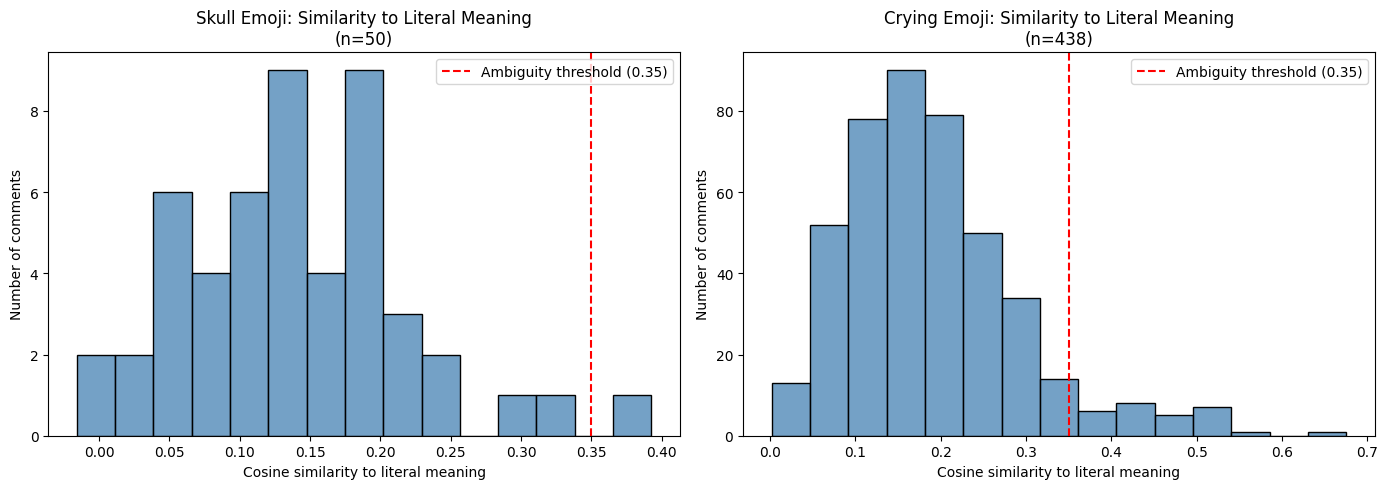

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (analysis, label) in zip(
    axes,
    [(skull_analysis, "Skull Emoji"), (cry_analysis, "Crying Emoji")]
):
    sns.histplot(analysis["semantic_similarity"], bins=15, ax=ax, color="steelblue")
    ax.axvline(THRESHOLD, color="red", linestyle="--", label=f"Ambiguity threshold ({THRESHOLD})")
    ax.set_title(f"{label}: Similarity to Literal Meaning\n(n={len(analysis)})")
    ax.set_xlabel("Cosine similarity to literal meaning")
    ax.set_ylabel("Number of comments")
    ax.legend()

plt.tight_layout()
plt.savefig("similarity_distributions.png", dpi=150)
plt.show()


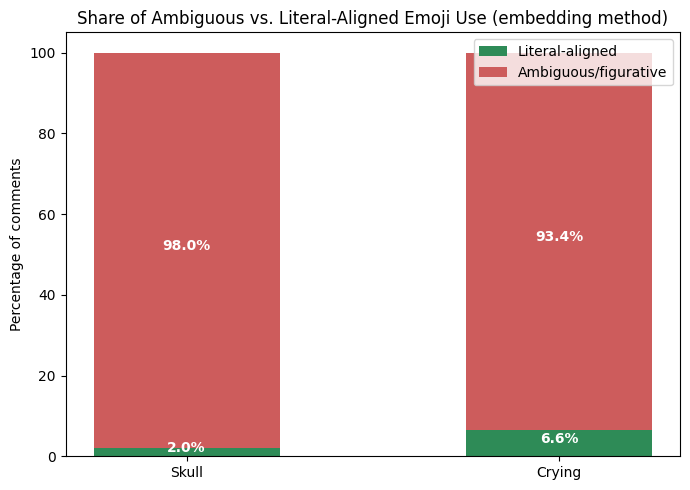

In [ ]:
# Bar chart: ambiguous vs literal-aligned proportion, side by side
import numpy as np

labels = ["Skull", "Crying"]
ambiguous_pct = [skull_analysis["ambiguous"].mean() * 100, cry_analysis["ambiguous"].mean() * 100]
literal_pct = [100 - p for p in ambiguous_pct]

x = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, literal_pct, width, label="Literal-aligned", color="seagreen")
ax.bar(x, ambiguous_pct, width, bottom=literal_pct, label="Ambiguous/figurative", color="indianred")

ax.set_ylabel("Percentage of comments")
ax.set_title("Share of Ambiguous vs. Literal-Aligned Emoji Use (embedding method)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i, (lit, amb) in enumerate(zip(literal_pct, ambiguous_pct)):
    ax.text(i, lit / 2, f"{lit:.1f}%", ha="center", color="white", fontweight="bold")
    ax.text(i, lit + amb / 2, f"{amb:.1f}%", ha="center", color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("ambiguity_proportions.png", dpi=150)
plt.show()


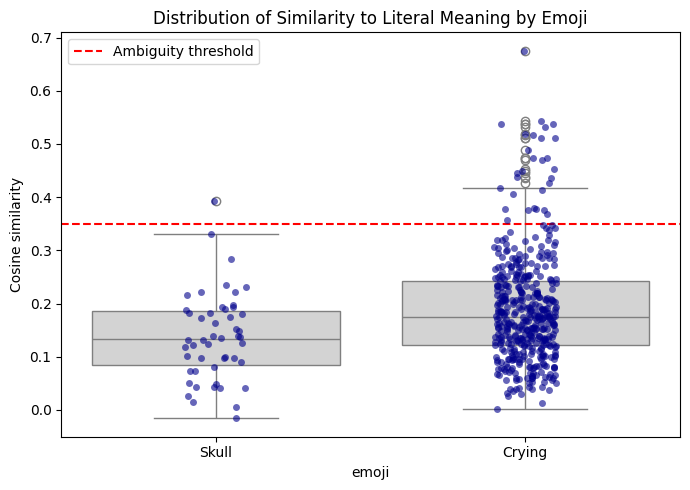

In [ ]:
# Side-by-side distribution comparison (box + individual points)
import pandas as pd

combined = pd.concat([
    skull_analysis.assign(emoji="Skull"),
    cry_analysis.assign(emoji="Crying")
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=combined, x="emoji", y="semantic_similarity", ax=ax, color="lightgray")
sns.stripplot(data=combined, x="emoji", y="semantic_similarity", ax=ax, color="darkblue", alpha=0.6, jitter=True)
ax.axhline(THRESHOLD, color="red", linestyle="--", label="Ambiguity threshold")
ax.set_title("Distribution of Similarity to Literal Meaning by Emoji")
ax.set_ylabel("Cosine similarity")
ax.legend()

plt.tight_layout()
plt.savefig("boxplot_comparison.png", dpi=150)
plt.show()


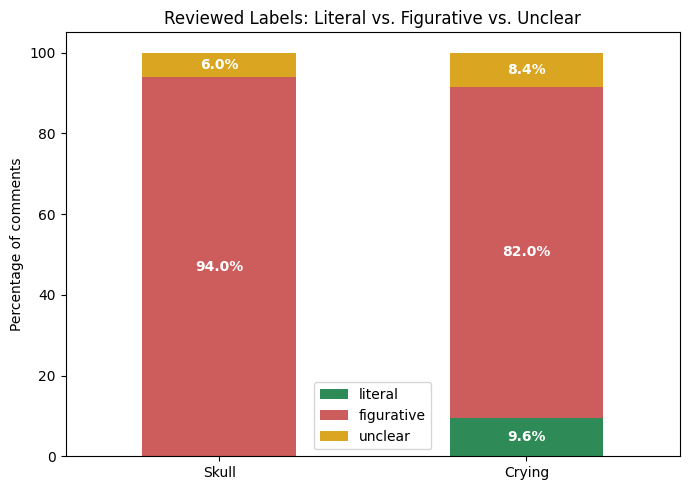

In [ ]:
# Reviewed-label distribution (literal / figurative / unclear) for each emoji
import pandas as pd

order = ["literal", "figurative", "unclear"]
dist = pd.DataFrame({
    "Skull": skull_eval["final_sense"].value_counts(normalize=True).reindex(order).fillna(0) * 100,
    "Crying": cry_eval["final_sense"].value_counts(normalize=True).reindex(order).fillna(0) * 100,
}).T[order]

ax = dist.plot(kind="bar", stacked=True, figsize=(7, 5),
               color=["seagreen", "indianred", "goldenrod"], rot=0)
ax.set_ylabel("Percentage of comments")
ax.set_title("Reviewed Labels: Literal vs. Figurative vs. Unclear")
for i, (_, row) in enumerate(dist.iterrows()):
    bottom = 0
    for col in order:
        v = row[col]
        if v >= 3:
            ax.text(i, bottom + v / 2, f"{v:.1f}%", ha="center", va="center", color="white", fontweight="bold")
        bottom += v
ax.legend(title="")
plt.tight_layout()
plt.savefig("reviewed_label_distribution.png", dpi=150)
plt.show()


## Results Summary

**Reviewed labels (main result).** After removing flagged comments, 438 crying-face and 50 skull comments were usable.

| | Usable comments | Literal | Figurative | Unclear | Not literal (95% CI) |
|---|---|---|---|---|---|
| Crying | 438 | 42 (9.6%) | 359 (82.0%) | 37 (8.4%) | 90.4% (87.3% to 92.8%) |
| Skull | 50 | 0 (0%) | 47 (94.0%) | 3 (6.0%) | 100% (92.9% to 100%) |

In this sample the great majority of uses of both emoji are not literal, and none of the 50 skull comments used the skull for its literal meaning of death or danger. The share of comments that even a careful reader marked unclear (8.4% crying, 6.0% skull) is a direct, model-independent sign that context does not always settle which sense is meant.

**Embedding cross-check.** The validation cell above reports how closely the semantic-similarity scores agree with these labels at the chosen threshold.

(The table above was computed from the label files; update it if the labels change.)

## Limitations

- **Sample.** The skull sample is small (50 comments) and contains no literal uses, so its literal rate is only bounded (the 95% interval for literal use is roughly 0% to 7%). Results come from one platform and one month (Reddit, May 2019).
- **Labels.** 85 crying-face labels were written by hand; the rest were labeled by an LLM and reviewed by the author, not independently labeled. Judgments of "figurative" versus "unclear" involve interpretation, and a few borderline rules (for example endearment and meme phrases such as "I'm not crying, you're crying") were decided by convention.
- **Embedding method.** The literal-meaning anchors were chosen by hand. The score measures closeness to those anchor phrases rather than literal use itself, so jokes about crying can score high. The model is a general-purpose English model, and the threshold was tuned on the same data it is evaluated on.
- **Filtering.** Spam, duplicate, and non-English comments were removed with simple rules, which may miss some cases.
